In [2]:
import matplotlib.pyplot as plt
import numpy as np

mean = 0 
std_dev = .01
epsilon = .1

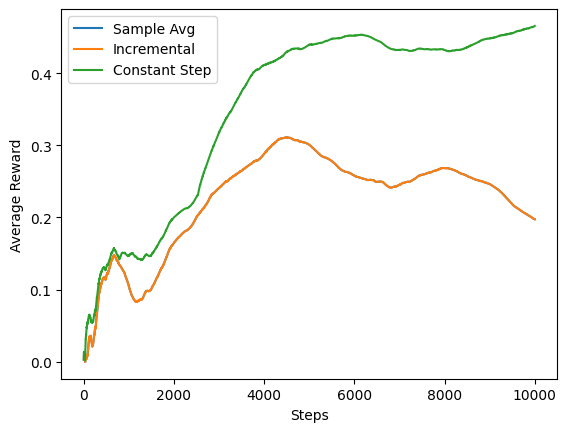

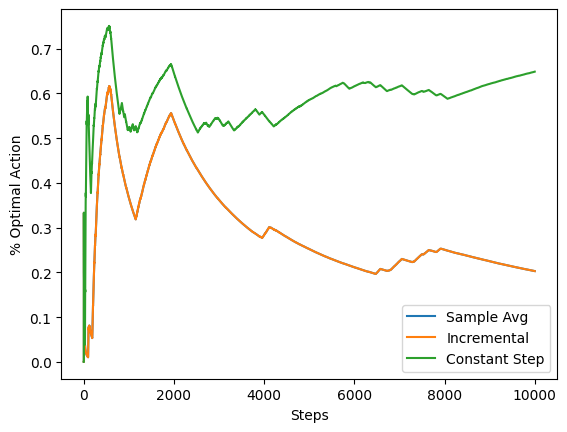

In [5]:
#build sample average function 
#returns avg reward and times optimal action was picked per step (for later graphing)
def sample_average(k, steps = 10000, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    q = np.zeros(k) # actual action values
    Q = np.zeros(k) # predictions
    N = np.zeros(k) # number of times that action was picked 
    R = [[] for i in range (k)] # store rewards per action to later compute the action value  
    #keep track for graphing later
    avg_rewards=np.zeros(steps)
    optimal_picked_percents = np.zeros(steps)
    optimal_picked = 0
    running_reward = 0
    for step in range(steps):
        #actual action values take indepent random walks and get incremented 
        # for a in range(k): 
        #     q[a] += np.random.normal(loc=mean, scale=std_dev ) #for loop version

        #vectorized 
        q += rng.normal(loc=mean, scale=std_dev, size=k)

        # e greedy for action choice 
        threshold = 1-epsilon
        action = 0 
        optimal_action = np.argmax(q)
        if rng.random() < threshold:  
            action = np.argmax(Q)
        else:
            action = rng.integers(k)
        
        if action == optimal_action : optimal_picked +=1 

        reward = q[action] #bandit
        R[action].append(reward)

        N[action] +=1 
        # compute sample avg 
        
        Q[action] = sum(R[action] ) / N[action]

        #update for graphs 
        running_reward += reward
        avg_rewards[step] = running_reward/ (step+1) 
        optimal_picked_percents [step] = optimal_picked/(step+1)
    
    return avg_rewards, optimal_picked_percents

def incremental(k, steps=10000, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    q = np.zeros(k) # actual action values
    Q = np.zeros(k) # predictions
    N = np.zeros(k) # number of times that action was picked 
    #keep track for graphing later
    avg_rewards=np.zeros(steps)
    optimal_picked_percents = np.zeros(steps)
    optimal_picked = 0
    running_reward = 0
    for step in range(steps):
        
        q += rng.normal(loc=mean, scale=std_dev, size=k)

        # e greedy for action choice 
        threshold = 1-epsilon
        action = 0 
        optimal_action = np.argmax(q)
        if rng.random() < threshold:  
            action = np.argmax(Q)
        else:
            action = rng.integers(k)
        
        if action == optimal_action : optimal_picked +=1 

        reward = q[action] #bandit
        

        N[action] +=1 
        # compute sample avg 
        
        Q[action] += (1/N[action]) *(reward - Q[action])

        #update for graphs 
        running_reward += reward
        avg_rewards[step] = running_reward/ (step+1) 
        optimal_picked_percents [step] = optimal_picked/(step+1)
    
    return avg_rewards, optimal_picked_percents

def constant_step_size(k, steps =10000, alpha = .1, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    q = np.zeros(k) # actual action values
    Q = np.zeros(k) # predictions
    N = np.zeros(k) # number of times that action was picked 
    #keep track for graphing later
    avg_rewards=np.zeros(steps)
    optimal_picked_percents = np.zeros(steps)
    optimal_picked = 0
    running_reward = 0
    for step in range(steps):
        
        q += rng.normal(loc=mean, scale=std_dev, size=k)

        # e greedy for action choice 
        threshold = 1-epsilon
        action = 0 
        optimal_action = np.argmax(q)
        if rng.random() < threshold:  
            action = np.argmax(Q)
        else:
            action = rng.integers(k)
        
        if action == optimal_action : optimal_picked +=1 

        reward = q[action] #bandit
        

        N[action] +=1 
        # compute sample avg 
        
        Q[action] += (alpha) *(reward - Q[action])

        #update for graphs 
        running_reward += reward
        avg_rewards[step] = running_reward/ (step+1) 
        optimal_picked_percents [step] = optimal_picked/(step+1)
    
    return avg_rewards, optimal_picked_percents

SEED =42
k= 10

sAvg, sOpt = sample_average(k,      rng=np.random.default_rng(SEED))
iAvg, iOpt = incremental(k,         rng=np.random.default_rng(SEED))
cAvg, cOpt = constant_step_size(k,  rng=np.random.default_rng(SEED))

steps = np.arange(1, sAvg.size+1)

fig, ax = plt.subplots()
ax.plot(steps, sAvg, label='Sample Avg')
ax.plot(steps, iAvg, label='Incremental')
ax.plot(steps, cAvg, label='Constant Step')
ax.legend()
ax.set_xlabel("Steps")
ax.set_ylabel("Average Reward")

fig2, ax2 = plt.subplots()
ax2.plot(steps, sOpt, label='Sample Avg')
ax2.plot(steps, iOpt, label='Incremental')
ax2.plot(steps, cOpt, label='Constant Step')
ax2.legend()
ax2.set_xlabel("Steps")
ax2.set_ylabel("% Optimal Action")
plt.show()